# UdaciSense: Optimized Object Recognition

## Notebook 1: Baseline Performance

In this notebook, you'll establish the baseline performance of the computer vision model. This will serve as the reference point for your optimization efforts.

Remember, the CTO has set specific requirements:
- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

### Step 1. Set up the environment

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import sys
import time
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset

# Ensure project root (starter-kit) is on sys.path
cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent, cwd / "starter-kit", cwd.parent / "starter-kit"]
for candidate in candidate_roots:
    if (candidate / "utils").exists():
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        break

# Import custom modules
from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, print_model_summary, train_model
from utils.evaluation import calculate_confusion_matrix, evaluate_model_metrics
from utils.visualization import plot_confusion_matrix, plot_training_history, plot_weight_distribution

In [3]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

# Set device to cuda, if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Devices available: ['cpu', 'cuda:0 (Tesla T4)']
Using device: cuda


In [4]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    # Basic seed setting
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Make cudnn deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # For some PyTorch operations
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    # For DataLoader workers
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

In [5]:
# Create directories
model_type = "baseline_mobilenet"
models_dir = f"../models/{model_type}"
models_ckp_dir = f"{models_dir}/checkpoints"
results_dir = f"../results/{model_type}"

os.makedirs(models_ckp_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

### Step 2. Load the dataset

Extracting household classes from CIFAR100 for train set...
Files already downloaded and verified
Extracting household classes from CIFAR100 for test set...
Files already downloaded and verified
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


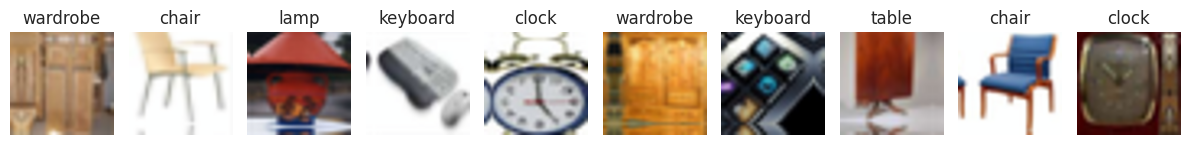


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


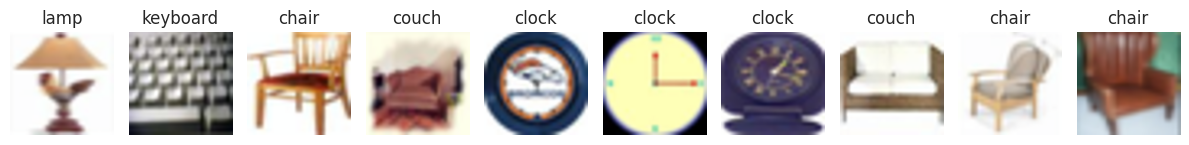

In [6]:
# Target input resolution for the model.
# The resize now lives in preprocessing (not inside the model), so input
# resolution is an explicit latency lever. 224 reproduces the original
# MobileNetV3 contract; lower values (160/128/112/96) are swept in the pipeline.
BASELINE_RESIZE = 224

# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2, resize=BASELINE_RESIZE,
)

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)


### Step 3. Train the baseline model

In [7]:
# Initialize model
model = MobileNetV3_Household().to(device)
print_model_summary(model)

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

In [8]:
# Define training configuration
num_epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,  # Note that MobileNet is sensitive to high LRs
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.005,  # Peak learning rate
    steps_per_epoch=len(train_loader),
    epochs=num_epochs,
    pct_start=0.3,  # Spend 30% of training time warming up
    div_factor=25,  # Initial LR is max_lr/25
    final_div_factor=1000  # Final LR is max_lr/1000
)

training_config = {
    'num_epochs': num_epochs,
    'criterion': criterion,
    'optimizer': optimizer,
    'scheduler': scheduler,
    'patience': 5,
    'device': device
}

In [9]:
# Train model given the training_config
training_stats, best_accuracy, best_epoch = train_model(
    model,
    train_loader,
    test_loader,
    training_config,
    checkpoint_path=f"{models_ckp_dir}/model.pth",
)

# Save training statistics
with open(f"{results_dir}/training_stats.json", 'w') as f:
    json.dump(training_stats, f, indent=4)

Total parameters: 1,528,106
Training with standard method for 50 epochs


Epoch 1/50 [Test]: 100%|██████████| 8/8 [00:02<00:00,  3.86it/s, loss=1.09, acc=62.3]


Epoch 1/50 - Train Loss: 1.5916, Train Acc: 52.46%, Test Loss: 1.0869, Test Acc: 62.30%, LR: 0.000200, Time: 13.02s
New best model! Saving... (62.30%)
Model saved to ../models/baseline_mobilenet/checkpoints/model.pth


Epoch 2/50 [Test]: 100%|██████████| 8/8 [00:02<00:00,  3.60it/s, loss=0.91, acc=67.3] 


Epoch 2/50 - Train Loss: 0.7534, Train Acc: 74.92%, Test Loss: 0.9095, Test Acc: 67.30%, LR: 0.000200, Time: 12.36s
New best model! Saving... (67.30%)
Model saved to ../models/baseline_mobilenet/checkpoints/model.pth


...

Epoch 18/50 - Train Loss: 0.0496, Train Acc: 98.46%, Test Loss: 0.5179, Test Acc: 87.20%, LR: 0.000211, Time: 13.06s


Epoch 19/50 [Test]: 100%|██████████| 8/8 [00:02<00:00,  3.91it/s, loss=0.508, acc=87.5]


Epoch 19/50 - Train Loss: 0.0394, Train Acc: 98.64%, Test Loss: 0.5082, Test Acc: 87.50%, LR: 0.000212, Time: 12.53s


Epoch 20/50 [Test]: 100%|██████████| 8/8 [00:01<00:00,  4.01it/s, loss=0.542, acc=87.8]

Epoch 20/50 - Train Loss: 0.0373, Train Acc: 99.06%, Test Loss: 0.5419, Test Acc: 87.80%, LR: 0.000213, Time: 12.06s
Early stopping at epoch 20. No improvement for 5 epochs.
Training completed. Best accuracy: 88.40%
Best model saved as '../models/baseline_mobilenet/checkpoints/model.pth' at epoch 15


### Step 4. Evaluate the baseline model

/workspace/code/project/starter-kit/utils/model.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(path, map_location=device)


Evaluating model's performance on all metrics...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.94it/s]


Baseline metrics saved at ../results/baseline_mobilenet/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:01<00:00,  5.02it/s]


Confusion matrix saved to ../results/baseline_mobilenet/confusion_matrix.png


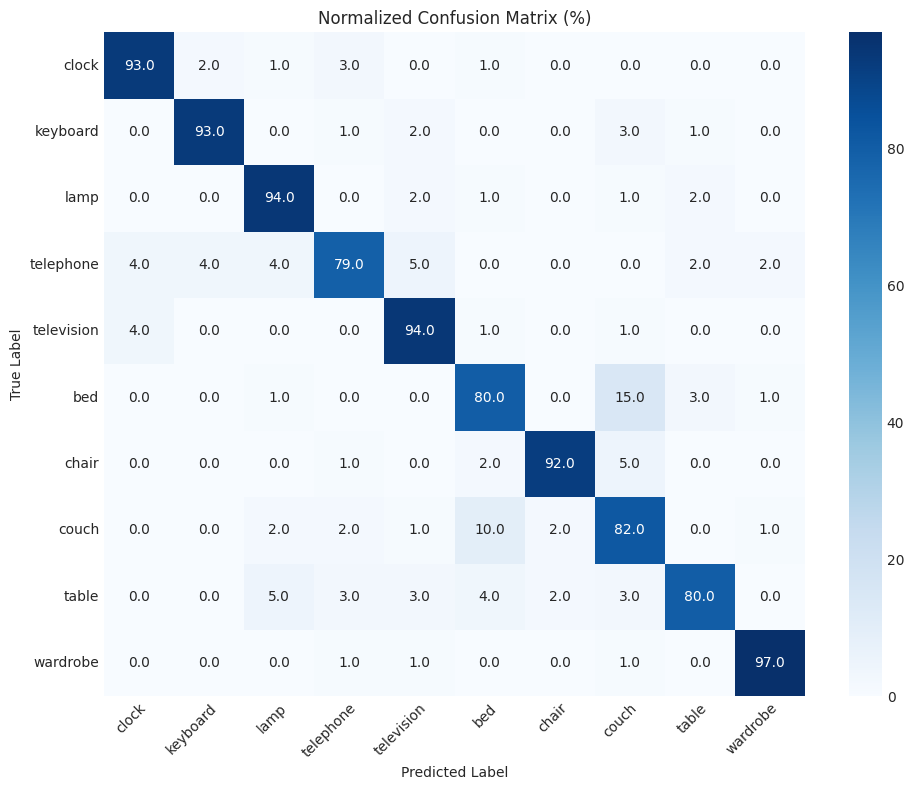

Training history plot saved to ../results/baseline_mobilenet/training_history.png


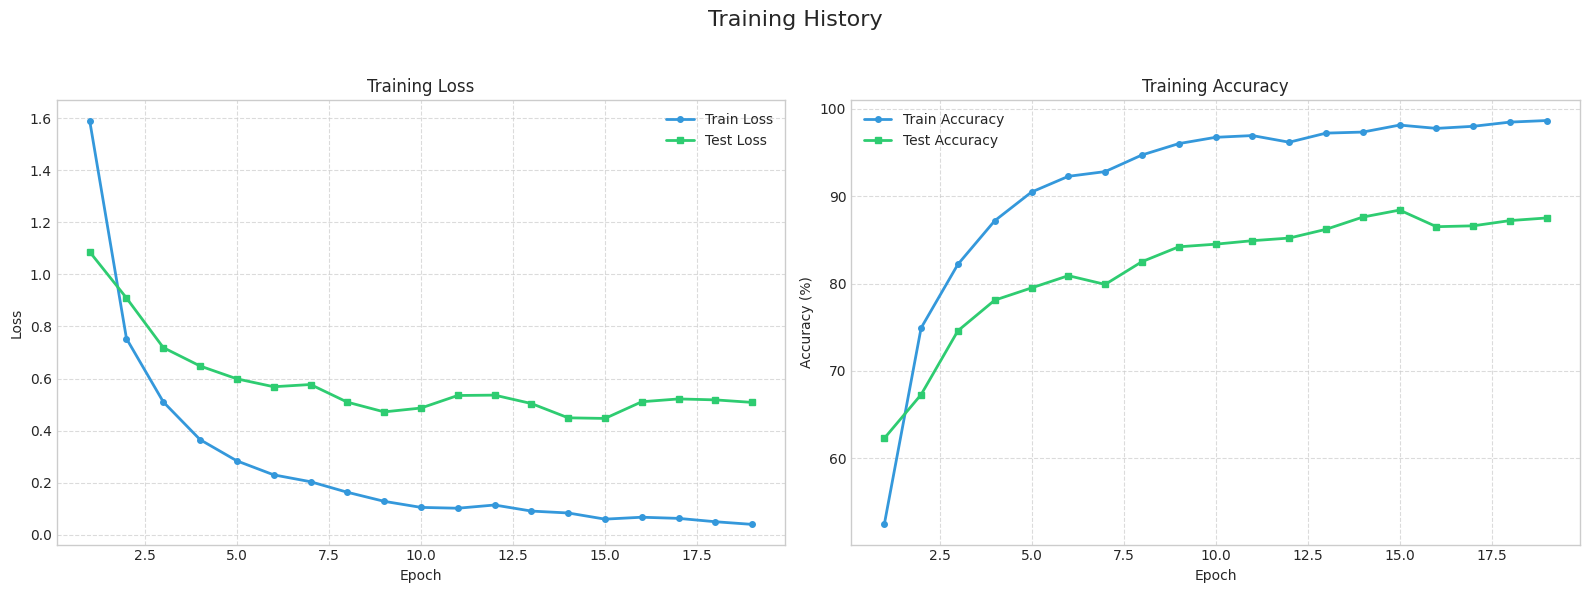

Weight distribution plot saved to ../results/baseline_mobilenet/weight_distribution.png


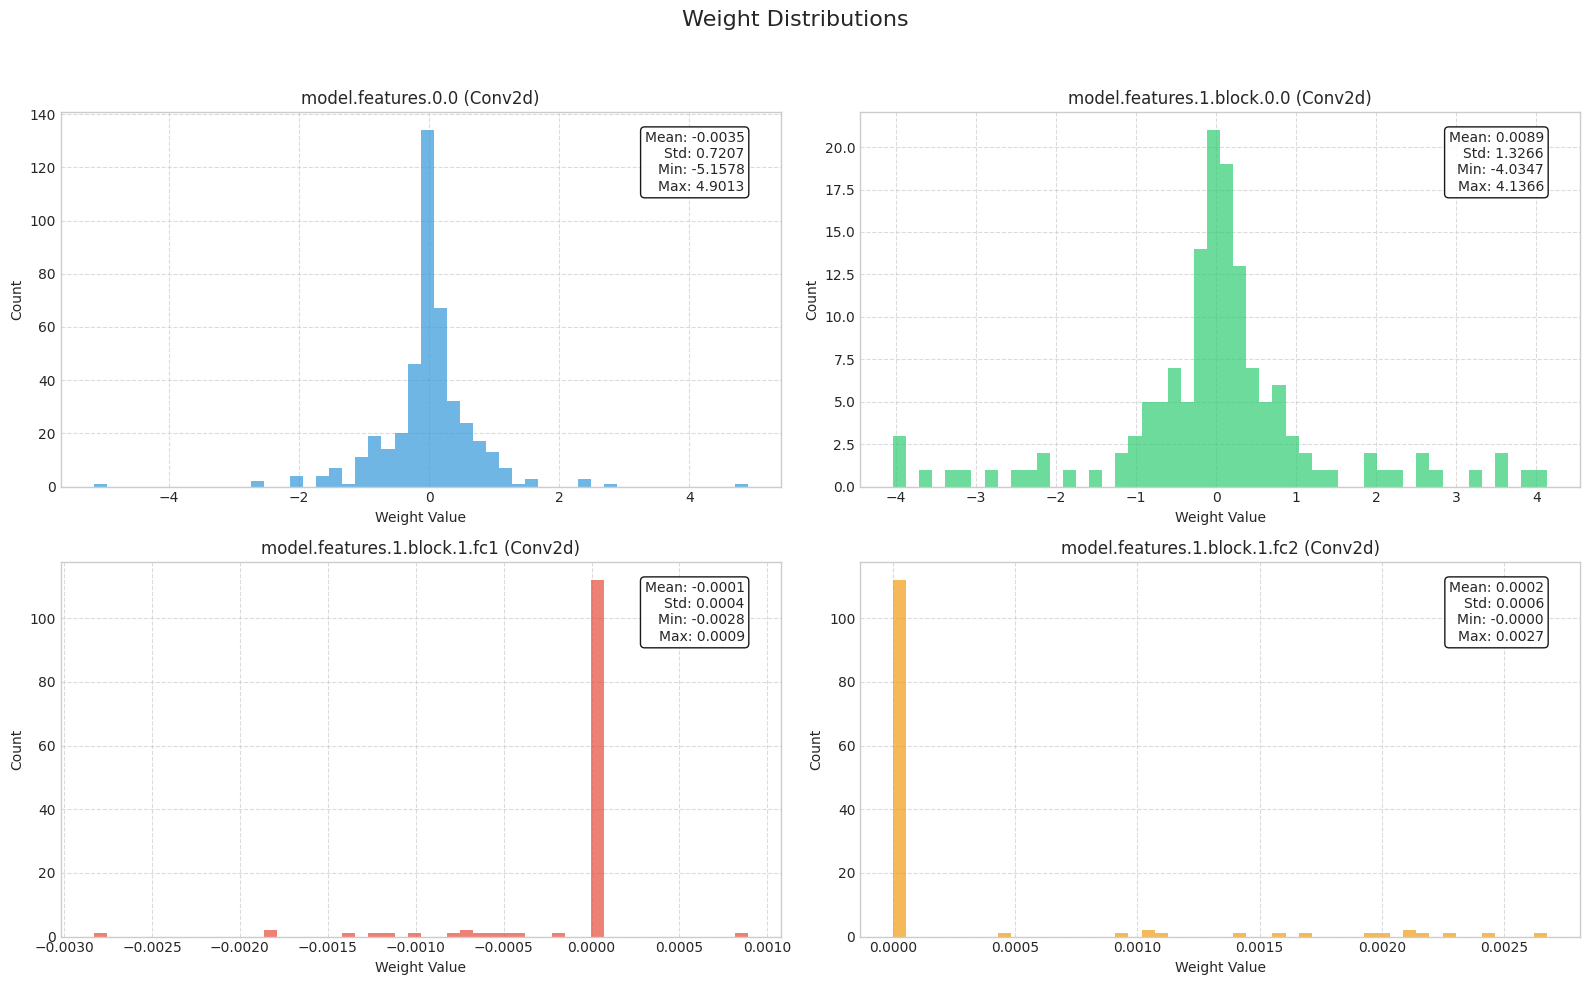

In [10]:
# Load the best model
model = load_model(f"{models_ckp_dir}/model.pth", device)

# Define evaluation input and output variables
class_names = test_loader.dataset.classes
n_classes = len(class_names)
input_size = get_input_size("CIFAR")

# Calculate and save model performance on all metrics
print("Evaluating model's performance on all metrics...")
baseline_metrics = evaluate_model_metrics(model, test_loader, device, n_classes, class_names, input_size, save_path=f"{results_dir}/metrics.json")

# Calculate, plot, and save confusion matrix
confusion_matrix = calculate_confusion_matrix(model, test_loader, device, n_classes)
_ = plot_confusion_matrix(confusion_matrix, class_names, f"{results_dir}/confusion_matrix.png")

# Plot and save training history
_ = plot_training_history(training_stats, f"{results_dir}/training_history.png")

# Plot weight distribution (can help guide optimization strategies)
_ = plot_weight_distribution(model, output_path=f"{results_dir}/weight_distribution.png")

### Step 5. Identify potential optimization approaches
Based on our baseline analysis, let's identify promising optimization approaches.

In [11]:
print(f"\nAll artifacts saved to:")
print(f" - Model: {models_ckp_dir}/model.pth")
print(f" - Metrics: {results_dir}/metrics.json")
print(f" - Confusion Matrix: {results_dir}/confusion_matrix.png")
print(f" - Training History: {results_dir}/training_history.png")
print(f" - Training Stats: {results_dir}/training_stats.json")
print(f" - Weight Distribution: {results_dir}/weight_distribution.png")


All artifacts saved to:
 - Model: ../models/baseline_mobilenet/checkpoints/model.pth
 - Metrics: ../results/baseline_mobilenet/metrics.json
 - Confusion Matrix: ../results/baseline_mobilenet/confusion_matrix.png
 - Training History: ../results/baseline_mobilenet/training_history.png
 - Training Stats: ../results/baseline_mobilenet/training_stats.json
 - Weight Distribution: ../results/baseline_mobilenet/weight_distribution.png


In [12]:
# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Optimization Targets:
Target Model Size: 5.96 --> 4.17 MB (30.0% reduction)
Target Inference Time (CPU): 5.34 --> 3.21 ms (40.0% reduction)
Target Inference Time (GPU): 5.85 --> 3.51 ms (40.0% reduction)
Minimum Acceptable Accuracy: 88.40 --> 83.98 (within 5.0% of baseline)


In [13]:
# Baseline summary and architecture hotspot analysis
from collections import defaultdict

# 1) Compact baseline summary for quick decision making
baseline_summary = {
    "model_size_mb": baseline_metrics["size"]["model_size_mb"],
    "cpu_inference_ms": baseline_metrics["timing"]["cpu"]["avg_time_ms"],
    "top1_accuracy": baseline_metrics["accuracy"]["top1_acc"],
    "target_model_size_mb": target_model_size,
    "target_cpu_inference_ms": target_inference_time_cpu,
    "min_acceptable_accuracy": min_acceptable_accuracy,
}

if torch.cuda.is_available():
    baseline_summary["gpu_inference_ms"] = baseline_metrics["timing"]["cuda"]["avg_time_ms"]

print("Baseline Summary:")
print(f"- Model size: {baseline_summary['model_size_mb']:.2f} MB")
print(f"- CPU inference: {baseline_summary['cpu_inference_ms']:.2f} ms")
if "gpu_inference_ms" in baseline_summary:
    print(f"- GPU inference: {baseline_summary['gpu_inference_ms']:.2f} ms")
print(f"- Top-1 accuracy: {baseline_summary['top1_accuracy']:.4f}")
print("")
print("Targets:")
print(f"- Model size <= {baseline_summary['target_model_size_mb']:.2f} MB")
print(f"- CPU inference <= {baseline_summary['target_cpu_inference_ms']:.2f} ms")
print(f"- Top-1 accuracy >= {baseline_summary['min_acceptable_accuracy']:.4f}")

# 2) Analyze where parameters are concentrated
module_param_counts = defaultdict(int)
for name, param in model.named_parameters():
    if param.requires_grad:
        top_level_module = name.split(".")[0]
        module_param_counts[top_level_module] += param.numel()

total_trainable_params = sum(module_param_counts.values())
sorted_modules = sorted(module_param_counts.items(), key=lambda x: x[1], reverse=True)

print("\nTop parameter-heavy top-level modules:")
for module_name, param_count in sorted_modules[:10]:
    share = 100.0 * param_count / total_trainable_params
    print(f"- {module_name}: {param_count:,} params ({share:.2f}%)")

# 3) Layer-level hotspot scan to guide pruning/quantization
conv_linear_layers = []
for layer_name, layer in model.named_modules():
    if isinstance(layer, (nn.Conv2d, nn.Linear)):
        n_params = sum(p.numel() for p in layer.parameters() if p.requires_grad)
        if n_params > 0:
            conv_linear_layers.append((layer_name, layer.__class__.__name__, n_params))

conv_linear_layers = sorted(conv_linear_layers, key=lambda x: x[2], reverse=True)
top_layer_budget = sum(item[2] for item in conv_linear_layers[:10])

print("\nTop Conv/Linear layers by parameter count:")
for layer_name, layer_type, n_params in conv_linear_layers[:10]:
    share = 100.0 * n_params / total_trainable_params
    print(f"- {layer_name} ({layer_type}): {n_params:,} params ({share:.2f}%)")

print("\nHotspot concentration:")
print(f"- Top 10 Conv/Linear layers hold {100.0 * top_layer_budget / total_trainable_params:.2f}% of trainable params")

# 4) Persist analysis for later notebooks/reports
analysis_output_path = f"{results_dir}/architecture_analysis.json"
with open(analysis_output_path, "w") as f:
    json.dump(
        {
            "baseline_summary": baseline_summary,
            "total_trainable_params": int(total_trainable_params),
            "top_level_module_params": {k: int(v) for k, v in sorted_modules},
            "top_conv_linear_layers": [
                {"name": n, "type": t, "params": int(p)} for n, t, p in conv_linear_layers[:20]
            ],
        },
        f,
        indent=4,
    )
print(f"\nSaved architecture analysis: {analysis_output_path}")

Baseline Summary:
- Model size: 5.96 MB
- CPU inference: 5.34 ms
- GPU inference: 5.85 ms
- Top-1 accuracy: 88.4000

Targets:
- Model size <= 4.17 MB
- CPU inference <= 3.21 ms
- Top-1 accuracy >= 83.9800

Top parameter-heavy top-level modules:
- model: 1,528,106 params (100.00%)

Top Conv/Linear layers by parameter count:
- model.classifier.0 (Linear): 590,848 params (38.67%)
- model.features.10.block.2.fc2 (Conv2d): 83,520 params (5.47%)
- model.features.11.block.2.fc2 (Conv2d): 83,520 params (5.47%)
- model.features.10.block.2.fc1 (Conv2d): 83,088 params (5.44%)
- model.features.11.block.2.fc1 (Conv2d): 83,088 params (5.44%)
- model.features.10.block.0.0 (Conv2d): 55,296 params (3.62%)
- model.features.10.block.3.0 (Conv2d): 55,296 params (3.62%)
- model.features.11.block.0.0 (Conv2d): 55,296 params (3.62%)
- model.features.11.block.3.0 (Conv2d): 55,296 params (3.62%)
- model.features.12.0 (Conv2d): 55,296 params (3.62%)

Hotspot concentration:
- Top 10 Conv/Linear layers hold 78.56

---------

**TODO: Analyze the baseline results and select appropriate compression techniques**

Now that you've established the baseline performance metrics for the UdaciSense object recognition model, complete an analysis that explores the optimization potential for this specific model architecture.

Consider these guiding questions:
- What is the baseline performance we need to optimize from?
- What characteristics of MobileNetV3 affect its optimization potential?
- Which compression techniques are most promising for this architecture and why?
- What trade-offs do you anticipate between size, speed, and accuracy?
- How might different techniques complement each other in a multi-stage approach?

Provide a well-reasoned analysis that includes recommendations for at least two specific compression techniques to implement in the next notebook.

# Optimization Analysis for UdaciSense Computer Vision Model

## 1) Baseline Performance Snapshot
Use the printed values from the previous cells as the baseline reference:
- Model size (MB)
- Inference latency on CPU (and GPU if available)
- Top-1 test accuracy

These three values define the optimization boundary for the rest of the project:
- Size target: at least 30% reduction
- Speed target: at least 40% lower inference time
- Accuracy target: no more than 5% absolute drop from baseline

## 2) MobileNetV3 Characteristics That Affect Compression
MobileNetV3 is already an efficiency-oriented network, which changes how aggressive compression should be:
- Depthwise separable convolutions already remove much of the redundancy seen in standard convolutions.
- Inverted bottleneck blocks are sensitive to channel removal; overly aggressive pruning can hurt representational capacity.
- Squeeze-and-Excitation (SE) improves accuracy at low cost, but adds small fully connected components that can be quantized effectively.
- Late-stage 1x1 pointwise convolutions and classifier layers often carry a large share of parameters and are common compression hotspots.

## 3) Most Promising Compression Techniques
Based on the architecture and the hotspot analysis cell, the best initial candidates are:

### Technique A: Post-Training Quantization (PTQ)
Why it fits:
- Usually gives immediate model-size reduction with minimal engineering effort.
- Often improves CPU inference throughput due to int8 kernels.
- Typically preserves accuracy better than aggressive pruning when calibration data is representative.

Expected trade-off:
- Strong size/speed gains, small accuracy drop when calibrated correctly.

### Technique B: Structured Channel Pruning (Conservative)
Why it fits:
- Can reduce both parameter count and MACs when removing complete channels/filters.
- More deployment-friendly than unstructured sparsity on mobile/edge backends.
- Best applied to parameter-heavy pointwise/expansion layers identified in the analysis cell.

Expected trade-off:
- More tuning required than quantization.
- Potentially larger accuracy drop if prune ratio is too high in bottleneck-sensitive blocks.

## 4) Recommended Multi-Stage Strategy
A reliable sequence for meeting all CTO constraints is:
1. Apply PTQ first to capture fast size and latency wins.
2. Apply moderate structured pruning targeted at parameter hotspots.
3. Fine-tune briefly to recover accuracy.
4. Re-quantize (or move to QAT if needed) for final deployment quality.

This order minimizes risk by taking low-regret optimizations first and only escalating complexity if targets are not yet met.

## 5) Risk and Validation Plan
Key risks and mitigations:
- Risk: accuracy loss concentrated in visually similar classes.
  Mitigation: inspect confusion matrix deltas after each compression stage.
- Risk: latency gains differ between CPU and GPU.
  Mitigation: benchmark both paths with identical batch size and warm-up.
- Risk: over-pruning depthwise/inverted bottleneck paths.
  Mitigation: start with low prune ratios and protect early feature extractor blocks.

## 6) Final Recommendation for Notebook 2
Implement and compare at least these two pipelines in Notebook 2:
1. Baseline -> PTQ
2. Baseline -> Structured Pruning -> Fine-tune -> PTQ

Track model size, latency, and accuracy after every stage and stop at the first configuration that satisfies all three CTO requirements.

> 🚀 **Next Step:** 
> Experiment with the compression techniques you've chosen in notebook `02_compression.ipynb`  